In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os, warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (ModelCheckpoint, EarlyStopping, 
                                         ReduceLROnPlateau, CSVLogger)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)

BASE_DIR = Path().resolve().parent
DATA_DIR = BASE_DIR / "data"
MODELS_DIR = BASE_DIR / "models"
MODELS_DIR.mkdir(exist_ok=True)

TensorFlow version: 2.13.0
GPU available: False


In [15]:
# ═══ ALL SETTINGS — change only here ═══
IMG_SIZE    = 224        # image size (224x224 pixels)
BATCH_SIZE  = 32         # images per batch
EPOCHS      = 30         # max training epochs
LEARNING_RATE = 1e-4     # initial learning rate
SEED        = 42
# ════════════════════════════════════════

CLASS_NAMES = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
NUM_CLASSES = len(CLASS_NAMES)
print(f"Classes: {CLASS_NAMES}")
print(f"Image size: {IMG_SIZE}x{IMG_SIZE}")

Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Image size: 224x224


In [16]:
df = pd.read_csv(DATA_DIR / "metadata_cleaned.csv")

# Encode labels as numbers: akiec=0, bcc=1, ...
df['label'] = df['dx'].map({c: i for i, c in enumerate(CLASS_NAMES)})
df['label_str'] = df['dx']  # keep string version for generators

# Split: 70% train, 15% validation, 15% test
train_df, temp_df = train_test_split(df, test_size=0.30, 
                                      random_state=SEED, stratify=df['label'])
val_df, test_df   = train_test_split(temp_df, test_size=0.50, 
                                      random_state=SEED, stratify=temp_df['label'])

print(f"Train: {len(train_df):,}  |  Val: {len(val_df):,}  |  Test: {len(test_df):,}")
print(f"\nTrain class distribution:\n{train_df['dx'].value_counts()}")

Train: 7,010  |  Val: 1,502  |  Test: 1,503

Train class distribution:
dx
nv       4693
mel       779
bkl       769
bcc       360
akiec     229
vasc       99
df         81
Name: count, dtype: int64


In [17]:
# Compute weights: minority classes get higher weight
from sklearn.utils.class_weight import compute_class_weight

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_df['label'].values
)
class_weights = {i: w for i, w in enumerate(class_weights_array)}
print("Class weights (higher = rarer class gets more attention):")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name}: {class_weights[i]:.2f}")

Class weights (higher = rarer class gets more attention):
  akiec: 4.37
  bcc: 2.78
  bkl: 1.30
  df: 12.36
  mel: 1.29
  nv: 0.21
  vasc: 10.12


In [18]:
# Training generator: AUGMENT images to create variety
train_gen = ImageDataGenerator(
    rescale          = 1./255,
    rotation_range   = 20,
    width_shift_range= 0.1,
    height_shift_range=0.1,
    horizontal_flip  = True,
    vertical_flip    = True,
    zoom_range       = 0.1,
    brightness_range = [0.9, 1.1],
    fill_mode        = 'nearest'
)

# Validation/Test generator: NO augmentation, just rescale
val_gen = ImageDataGenerator(rescale=1./255)

# Create the actual data flows
train_flow = train_gen.flow_from_dataframe(
    train_df, x_col='filepath', y_col='label_str',
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True, seed=SEED
)
val_flow = val_gen.flow_from_dataframe(
    val_df, x_col='filepath', y_col='label_str',
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)
test_flow = val_gen.flow_from_dataframe(
    test_df, x_col='filepath', y_col='label_str',
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)
print("Generators ready!")
print(f"Steps per epoch: {len(train_flow)}")

Found 7010 validated image filenames belonging to 7 classes.
Found 1502 validated image filenames belonging to 7 classes.
Found 1503 validated image filenames belonging to 7 classes.
Generators ready!
Steps per epoch: 220


In [19]:
def build_model(num_classes, learning_rate):
    """
    EfficientNetB3 is a powerful pre-trained model (trained on 1.2M ImageNet images).
    We FREEZE its layers first, then add our own classification head on top.
    """
    # Load EfficientNetB3 WITHOUT its top classification layer
    base_model = EfficientNetB3(
        weights    = 'imagenet',   # pre-trained weights
        include_top= False,        # remove ImageNet's 1000-class head
        input_shape= (IMG_SIZE, IMG_SIZE, 3)
    )
    
    # Phase 1: Freeze ALL base model layers (only train our new head)
    base_model.trainable = False
    
    # Build our classification head
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)   # flatten feature maps
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)              # prevent overfitting
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)  # 7 classes
    
    model = keras.Model(inputs, outputs)
    
    model.compile(
        optimizer = keras.optimizers.Adam(learning_rate),
        loss      = 'categorical_crossentropy',
        metrics   = ['accuracy', 
                     keras.metrics.AUC(name='auc'),
                     keras.metrics.Precision(name='precision'),
                     keras.metrics.Recall(name='recall')]
    )
    return model, base_model

model, base_model = build_model(NUM_CLASSES, LEARNING_RATE)
model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 efficientnetb3 (Functional  (None, 7, 7, 1536)        10783535  
 )                                                               
                                                                 
 global_average_pooling2d_1  (None, 1536)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 batch_normalization_1 (Bat  (None, 1536)              6144      
 chNormalization)                                                
                                                                 
 dense_3 (Dense)             (None, 256)               393472    
                                                           

In [21]:
callbacks = [
    # Save the BEST model automatically
    ModelCheckpoint(
        filepath  = str(MODELS_DIR / "best_model.h5"),
        monitor   = 'val_accuracy',
        save_best_only= True,
        mode      = 'max',
        verbose   = 1
    ),
    # Stop early if no improvement for 10 epochs
    EarlyStopping(
        monitor  = 'val_accuracy',
        patience = 10,
        restore_best_weights=True,
        verbose  = 1
    ),
    # Reduce learning rate when stuck
    ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.5,
        patience = 5,
        min_lr   = 1e-7,
        verbose  = 1
    ),
    # Log all metrics to a CSV file
    CSVLogger(str(MODELS_DIR / "training_log.csv"))
]
print("Callbacks ready!")

Callbacks ready!


In [ ]:
print("=" * 50)
print("PHASE 1: Training only the new classification head")
print("=" * 50)

history_phase1 = model.fit(
    train_flow,
    epochs           = 15,
    validation_data  = val_flow,
    class_weight     = class_weights,
    callbacks        = callbacks,
    verbose          = 1
)

PHASE 1: Training only the new classification head
Epoch 1/15
220/220 [==============================] - ETA: 0s - loss: 1.9200 - accuracy: 0.4381 - auc: 0.7064 - precision: 0.2308 - recall: 8.5592e-04
Epoch 1: val_accuracy improved from -inf to 0.05260, saving model to C:\Users\anujm\Downloads\skin-cancer-detection\models\best_model.h5
220/220 [==============================] - 1322s 6s/step - loss: 1.9200 - accuracy: 0.4381 - auc: 0.7064 - precision: 0.2308 - recall: 8.5592e-04 - val_loss: 2.0474 - val_accuracy: 0.0526 - val_auc: 0.2100 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - lr: 1.0000e-04
Epoch 2/15
  7/220 [..............................] - ETA: 17:35 - loss: 2.0566 - accuracy: 0.3214 - auc: 0.7227 - precision: 0.0000e+00 - recall: 0.0000e+00

In [22]:
import pandas as pd

log = pd.read_csv("C:/Users/anujm/Downloads/skin-cancer-detection/models/training_log.csv")
print(log.tail())
print("Completed epochs:", len(log))

    epoch  accuracy       auc      loss      lr  precision    recall  \
8       8  0.417404  0.712111  1.790100  0.0001   0.929804  0.115264   
9       9  0.415977  0.707565  1.783393  0.0001   0.945829  0.124536   
10     10  0.424536  0.726216  1.757550  0.0001   0.945455  0.118688   
11     11  0.417546  0.709573  1.754495  0.0001   0.939747  0.137946   
12     12  0.407989  0.720891  1.741940  0.0001   0.909902  0.145506   

    val_accuracy   val_auc  val_loss  val_precision  val_recall  
8       0.430759  0.698421  1.705040       0.979167    0.062583  
9       0.434088  0.715669  1.644212       0.925170    0.181092  
10      0.448735  0.710751  1.686272       0.942857    0.087883  
11      0.444075  0.731398  1.613051       0.968127    0.161784  
12      0.455393  0.726773  1.614038       0.965517    0.186418  
Completed epochs: 13


In [23]:
from tensorflow.keras.models import load_model

model = load_model("C:/Users/anujm/Downloads/skin-cancer-detection/models/best_model.h5")

In [25]:
history = model.fit(
    train_flow,
    validation_data=val_flow,
    initial_epoch=13,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 14/15
220/220 [==============================] - ETA: 0s - loss: 1.7441 - accuracy: 0.4264 - auc: 0.7285 - precision: 0.9291 - recall: 0.1478
Epoch 14: val_accuracy improved from -inf to 0.45473, saving model to C:\Users\anujm\Downloads\skin-cancer-detection\models\best_model.h5
220/220 [==============================] - 977s 4s/step - loss: 1.7441 - accuracy: 0.4264 - auc: 0.7285 - precision: 0.9291 - recall: 0.1478 - val_loss: 1.6211 - val_accuracy: 0.4547 - val_auc: 0.7301 - val_precision: 0.9420 - val_recall: 0.1731 - lr: 1.0000e-04
Epoch 15/15
220/220 [==============================] - ETA: 0s - loss: 1.7406 - accuracy: 0.4057 - auc: 0.7218 - precision: 0.8770 - recall: 0.1566
Epoch 15: val_accuracy improved from 0.45473 to 0.45806, saving model to C:\Users\anujm\Downloads\skin-cancer-detection\models\best_model.h5
220/220 [==============================] - 957s 4s/step - loss: 1.7406 - accuracy: 0.4057 - auc: 0.7218 - precision: 0.8770 - recall: 0.1566 - val_loss: 1.5983 - 

In [27]:
print("=" * 50)
print("PHASE 2: Fine-tuning — unfreeze top 30 layers of EfficientNetB3")
print("=" * 50)

# Unfreeze the TOP 30 layers of the base model
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with a MUCH lower learning rate (don't destroy pre-trained weights!)
model.compile(
    optimizer = keras.optimizers.Adam(1e-5),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy', keras.metrics.AUC(name='auc'),
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall')]
)

history_phase2 = model.fit(
    train_flow,
    epochs           = EPOCHS,
    initial_epoch    = 15,
    validation_data  = val_flow,
    class_weight     = class_weights,
    callbacks        = callbacks,
    verbose          = 1
)
print("\nTraining complete! Best model saved to models/best_model.h5")

PHASE 2: Fine-tuning — unfreeze top 30 layers of EfficientNetB3
Epoch 16/30
220/220 [==============================] - ETA: 0s - loss: 1.7346 - accuracy: 0.4262 - auc: 0.7315 - precision: 0.9299 - recall: 0.1723
Epoch 16: val_accuracy improved from 0.45806 to 0.46005, saving model to C:\Users\anujm\Downloads\skin-cancer-detection\models\best_model.h5
220/220 [==============================] - 1169s 5s/step - loss: 1.7346 - accuracy: 0.4262 - auc: 0.7315 - precision: 0.9299 - recall: 0.1723 - val_loss: 1.5951 - val_accuracy: 0.4601 - val_auc: 0.7326 - val_precision: 0.9606 - val_recall: 0.1784 - lr: 1.0000e-05
Epoch 17/30
220/220 [==============================] - ETA: 0s - loss: 1.7341 - accuracy: 0.4265 - auc: 0.7293 - precision: 0.9252 - recall: 0.1642
Epoch 17: val_accuracy improved from 0.46005 to 0.46471, saving model to C:\Users\anujm\Downloads\skin-cancer-detection\models\best_model.h5
220/220 [==============================] - 1582s 7s/step - loss: 1.7341 - accuracy: 0.4265 - a

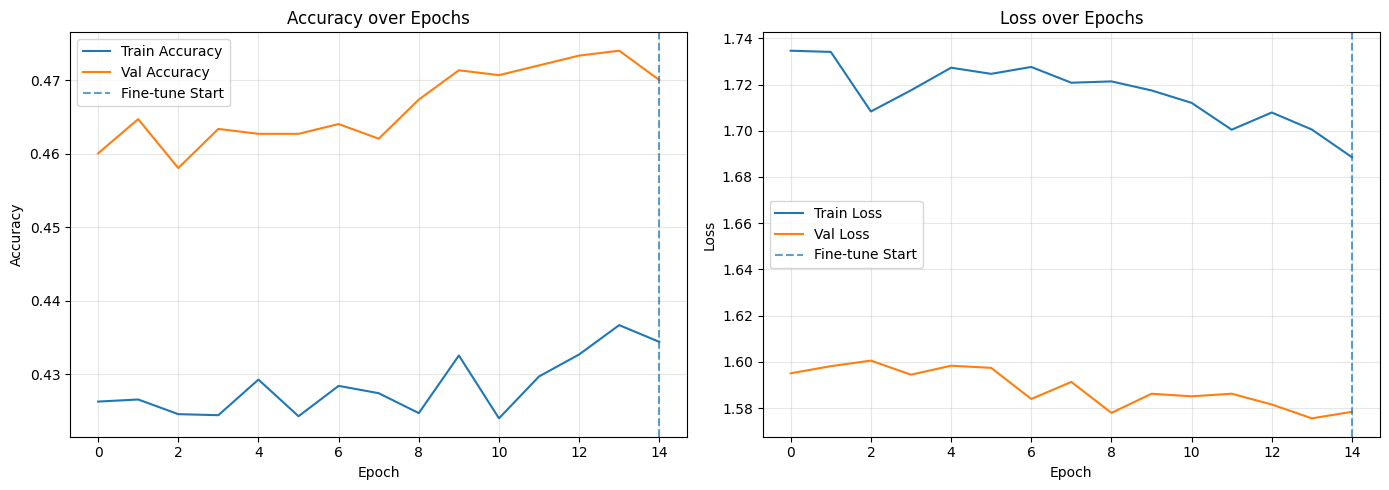

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

log = pd.read_csv("C:/Users/anujm/Downloads/skin-cancer-detection/models/training_log.csv")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))

# Accuracy
ax1.plot(log['accuracy'], label='Train Accuracy')
ax1.plot(log['val_accuracy'], label='Val Accuracy')
ax1.axvline(x=14, linestyle='--', alpha=0.7, label='Fine-tune Start')
ax1.set_title("Accuracy over Epochs")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss
ax2.plot(log['loss'], label='Train Loss')
ax2.plot(log['val_loss'], label='Val Loss')
ax2.axvline(x=14, linestyle='--', alpha=0.7, label='Fine-tune Start')
ax2.set_title("Loss over Epochs")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
# Load the BEST saved model
best_model = keras.models.load_model(str(MODELS_DIR / "best_model.h5"))

# Evaluate
print("Evaluating on test set...")
test_loss, test_acc, test_auc, test_prec, test_rec = best_model.evaluate(test_flow)
print(f"\n{'='*40}")
print(f"Test Accuracy : {test_acc*100:.2f}%")
print(f"Test AUC      : {test_auc:.4f}")
print(f"Test Precision: {test_prec:.4f}")
print(f"Test Recall   : {test_rec:.4f}")
print(f"{'='*40}")

Evaluating on test set...
47/47 [==============================] - 281s 6s/step - loss: 1.6090 - accuracy: 0.4431 - auc: 0.7309 - precision: 0.9628 - recall: 0.1896

Test Accuracy : 44.31%
Test AUC      : 0.7309
Test Precision: 0.9628
Test Recall   : 0.1896


47/47 [==============================] - 244s 5s/step

Classification Report:
              precision    recall  f1-score   support

       akiec       0.15      0.65      0.24        49
         bcc       0.12      0.22      0.16        77
         bkl       0.26      0.34      0.30       165
          df       0.00      0.00      0.00        17
         mel       0.27      0.39      0.32       167
          nv       0.94      0.49      0.64      1006
        vasc       0.02      0.14      0.04        22

    accuracy                           0.44      1503
   macro avg       0.25      0.32      0.24      1503
weighted avg       0.70      0.44      0.51      1503



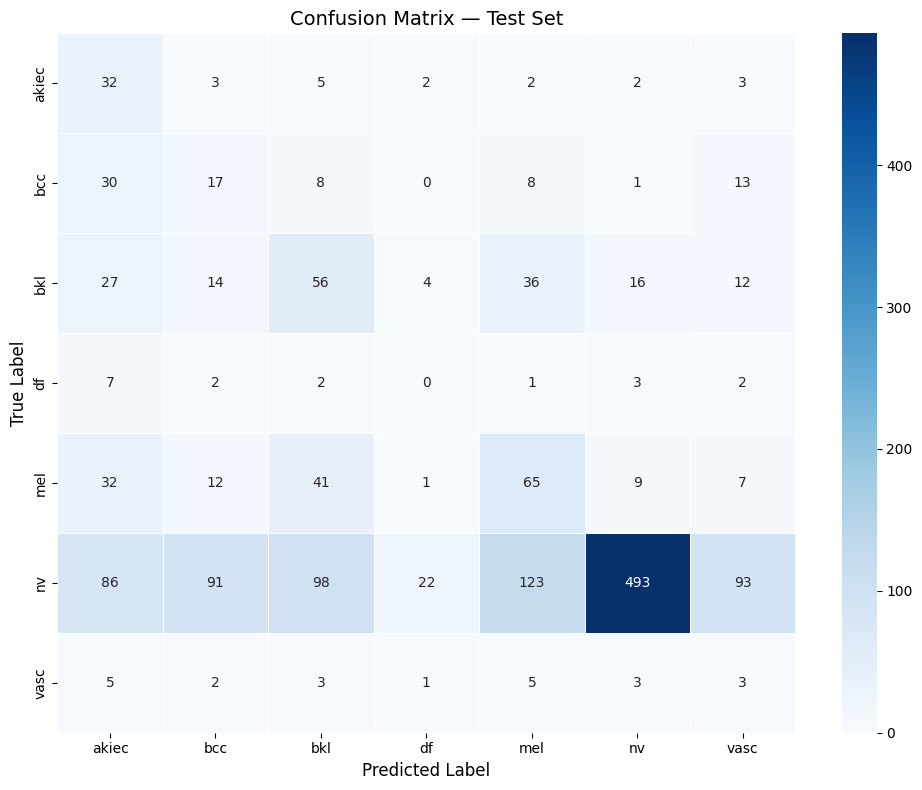

In [31]:
# Get predictions
test_flow.reset()
y_pred_probs = best_model.predict(test_flow, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_flow.classes

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5)
plt.title('Confusion Matrix — Test Set', fontsize=14)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig(str(MODELS_DIR / "confusion_matrix.png"), dpi=150, bbox_inches='tight')
plt.show()

In [32]:
import json
class_info = {
    'class_names': CLASS_NAMES,
    'label_map': {
        'akiec': 'Actinic Keratosis (Pre-cancer)',
        'bcc'  : 'Basal Cell Carcinoma',
        'bkl'  : 'Benign Keratosis (Benign)',
        'df'   : 'Dermatofibroma (Benign)',
        'mel'  : 'Melanoma ⚠️ (Dangerous)',
        'nv'   : 'Melanocytic Nevi / Mole (Common)',
        'vasc' : 'Vascular Lesion (Benign)'
    },
    'dangerous_classes': ['mel', 'bcc', 'akiec'],
    'img_size': IMG_SIZE
}
with open(str(MODELS_DIR / "class_info.json"), 'w') as f:
    json.dump(class_info, f, indent=2)
print("Saved class_info.json")
print("\nAll done! Your model is trained and saved.")

Saved class_info.json

All done! Your model is trained and saved.
